In [1]:
!pip install torch torchvision pandas matplotlib seaborn scikit-learn pillow tqdm

     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     --------------------- ------------------ 30.7/57.7 kB ? eta -:--:--
     -------------------------------------- 57.7/57.7 kB 765.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ----- --------------------------------- 41.0/294.9 kB 960.0 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/294.9 kB 960.0 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/294.9 kB 819.2 kB/s eta 0:00:01
   ------------------------------ --------- 225.3/294.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------- ----- 256.0/294.9 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
    --------------------------------------- 0.1/8.0 MB 6.4 MB/s eta 0:00:02
    --------------------------------------- 0.1/8.0 MB 6.4 MB/s eta 0:00:02
   


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

In [5]:
dataset_path = "C:/Users/vasan/Desktop/DFU Project/DFU_dataset/Transfer-Learning images"

folders = os.listdir(dataset_path)

print("Folders inside dataset:")
print(folders)

Folders inside dataset:
['internetSet', 'samples', 'Wound Images', 'Wound Images2']


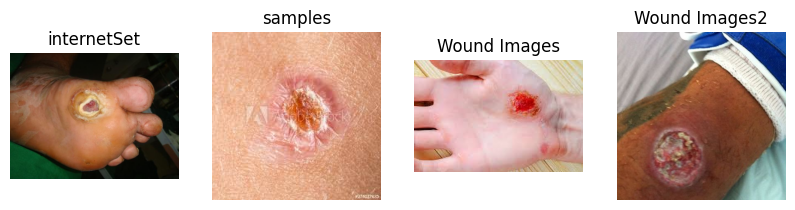

In [6]:
plt.figure(figsize=(10,5))

i = 1
for folder in folders:
    
    folder_path = os.path.join(dataset_path,folder)
    img_name = os.listdir(folder_path)[0]
    
    img_path = os.path.join(folder_path,img_name)
    img = Image.open(img_path)
    
    plt.subplot(1,len(folders),i)
    plt.imshow(img)
    plt.title(folder)
    plt.axis("off")
    
    i += 1

plt.show()

In [7]:
print("Loading ResNet50...")

model = models.resnet50(pretrained=True)

feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])

feature_extractor.eval()

print("ResNet50 Loaded Successfully")

Loading ResNet50...


c:\Users\vasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\vasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\vasan/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [01:28<00:00, 1.15MB/s]


ResNet50 Loaded Successfully


In [8]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [9]:
data = []

print("Starting Feature Extraction...")

for folder in folders:
    
    folder_path = os.path.join(dataset_path,folder)
    
    for image_name in tqdm(os.listdir(folder_path)):
        
        try:
            path = os.path.join(folder_path,image_name)
            
            img = Image.open(path).convert("RGB")
            img = transform(img).unsqueeze(0)
            
            with torch.no_grad():
                features = feature_extractor(img)
            
            features = features.squeeze().numpy()
            
            row = [image_name, folder]
            row.extend(features)
            
            data.append(row)
            
        except:
            print("Error:",image_name)

print("Feature Extraction Finished")

Starting Feature Extraction...


100%|██████████| 677/677 [01:40<00:00,  6.76it/s]

Feature Extraction Finished


In [10]:
columns = ["image","label"]

for i in range(2048):
    columns.append("f"+str(i+1))

df = pd.DataFrame(data,columns=columns)

df.to_csv("dfu_features.csv",index=False)

print("Feature dataset saved as dfu_features.csv")

Feature dataset saved as dfu_features.csv
